In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
df = pd.read_csv("bodyPerformance.csv")

In [26]:
df.isna().sum()

age                        0
gender                     0
height_cm                  0
weight_kg                  0
body fat_%                 0
diastolic                  0
systolic                   0
gripForce                  0
sit and bend forward_cm    0
sit-ups counts             0
broad jump_cm              0
class                      0
dtype: int64

In [27]:
df.dtypes

age                        float64
gender                      object
height_cm                  float64
weight_kg                  float64
body fat_%                 float64
diastolic                  float64
systolic                   float64
gripForce                  float64
sit and bend forward_cm    float64
sit-ups counts             float64
broad jump_cm              float64
class                       object
dtype: object

In [28]:
print('Datos antes de duplicados:',len(df))
df.drop_duplicates()
print('Datos después de duplicados:',len(df))

Datos antes de duplicados: 13393
Datos después de duplicados: 13393


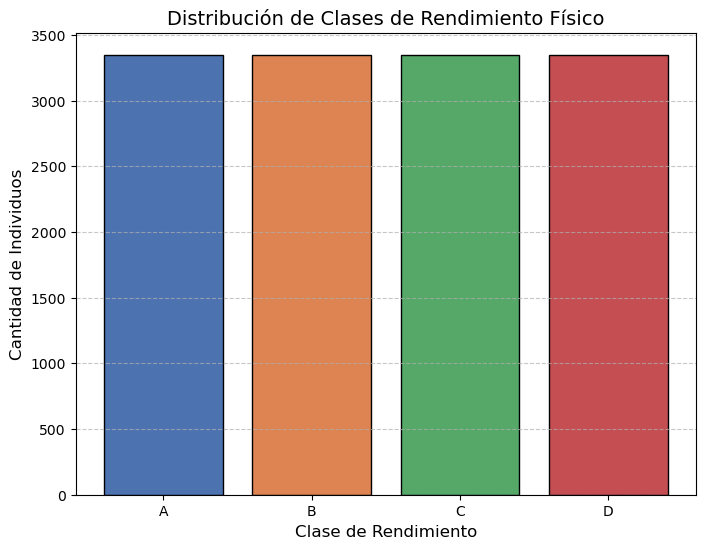

In [29]:
plt.figure(figsize=(8, 6))
class_counts = df['class'].value_counts().sort_index()
plt.bar(class_counts.index, class_counts.values, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'], edgecolor='black')
plt.title('Distribución de Clases de Rendimiento Físico', fontsize=14)
plt.xlabel('Clase de Rendimiento', fontsize=12)
plt.ylabel('Cantidad de Individuos', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
#plt.savefig('1_distribucion_clases.png', bbox_inches='tight')
plt.close()


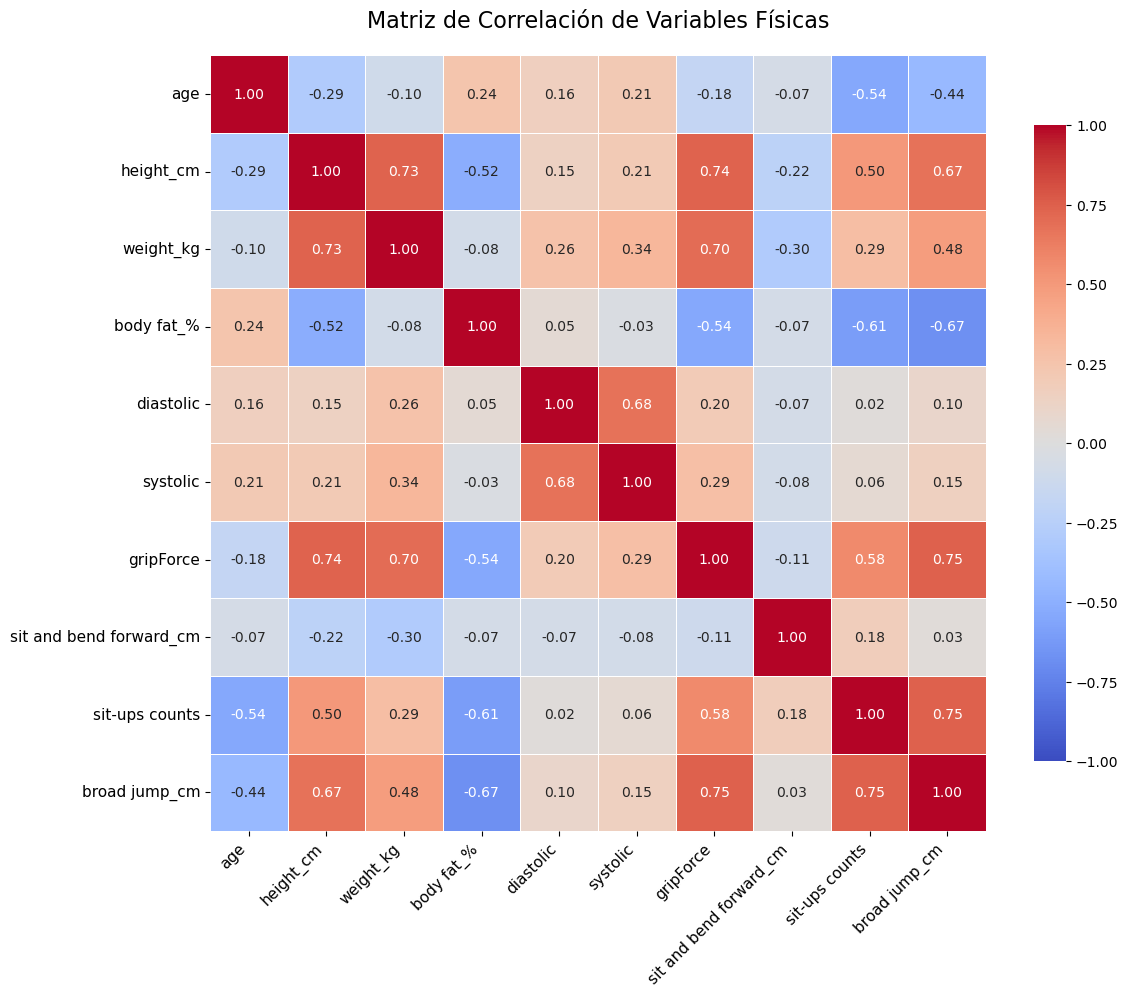

In [30]:
plt.figure(figsize=(12, 10))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

sns.heatmap(corr, 
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            vmin=-1, vmax=1,
            square=True,
            linewidths=.5,
            cbar_kws={"shrink": .8})

plt.title('Matriz de Correlación de Variables Físicas', pad=20, fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()
#plt.savefig('2_matriz_correlacion_seaborn.png')
plt.close()

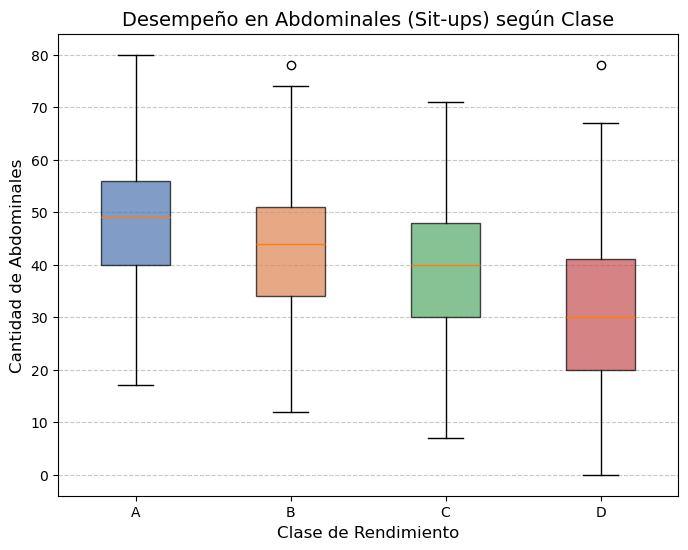

In [31]:
plt.figure(figsize=(8, 6))
classes = sorted(df['class'].unique())
data_to_plot = [df[df['class'] == c]['sit-ups counts'].dropna() for c in classes]
box = plt.boxplot(data_to_plot, patch_artist=True)
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
plt.xticks(range(1, len(classes) + 1), classes)
plt.title('Desempeño en Abdominales (Sit-ups) según Clase', fontsize=14)
plt.xlabel('Clase de Rendimiento', fontsize=12)
plt.ylabel('Cantidad de Abdominales', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
#plt.savefig('3_boxplot_rendimiento.png', bbox_inches='tight')
plt.close()

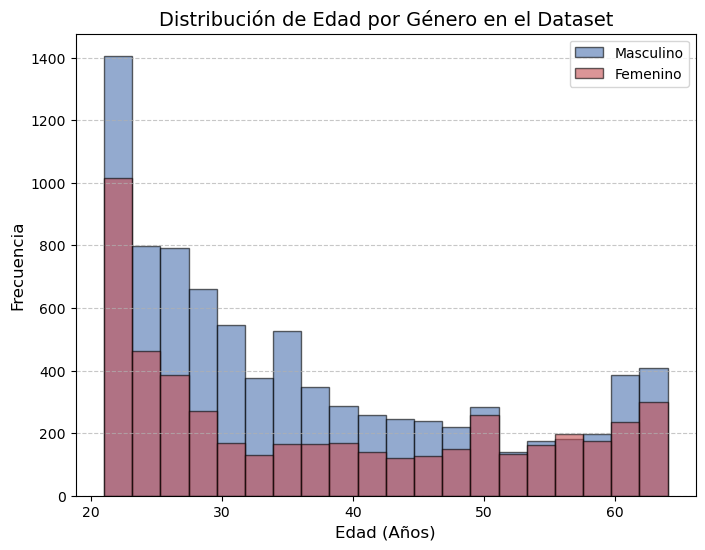

In [32]:
plt.figure(figsize=(8, 6))
plt.hist(df[df['gender']=='M']['age'], bins=20, alpha=0.6, label='Masculino', color='#4C72B0', edgecolor='black')
plt.hist(df[df['gender']=='F']['age'], bins=20, alpha=0.6, label='Femenino', color='#C44E52', edgecolor='black')
plt.title('Distribución de Edad por Género en el Dataset', fontsize=14)
plt.xlabel('Edad (Años)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
#plt.savefig('4_distribucion_edad.png', bbox_inches='tight')
plt.close()

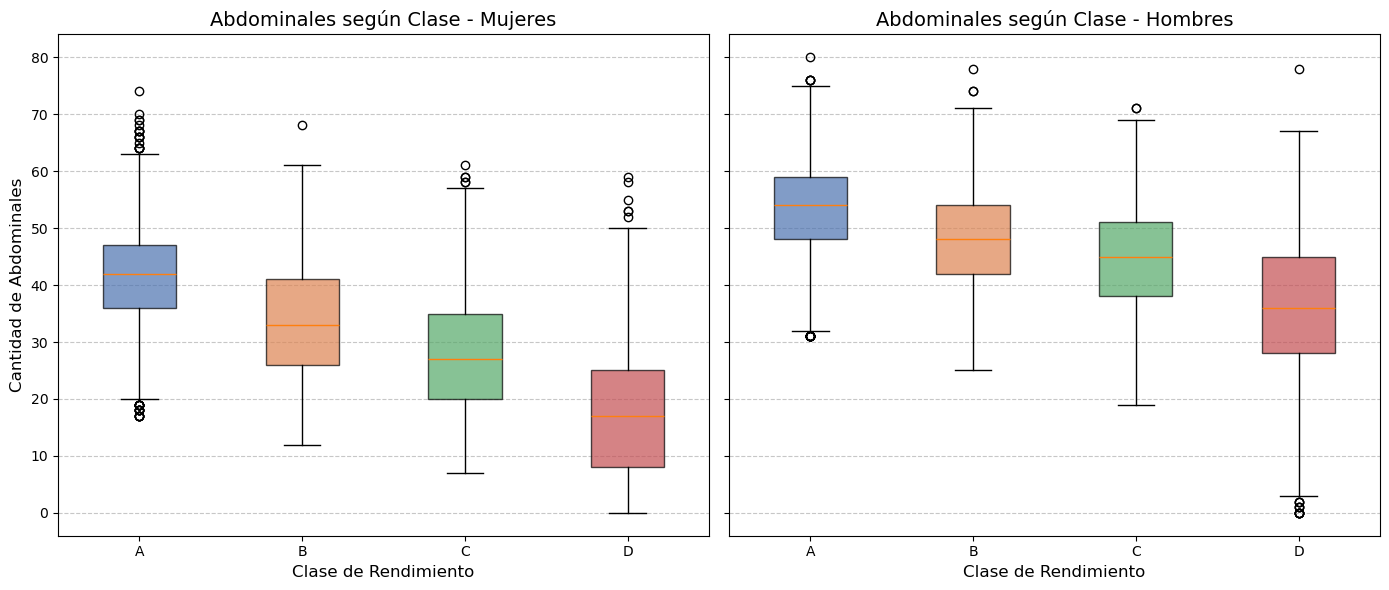

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

classes = sorted(df['class'].unique())
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# Mujeres
df_mujeres = df[df['gender'] == val_mujer]

data_mujeres = [df_mujeres[df_mujeres['class'] == c]['sit-ups counts'].dropna() for c in classes]

box_mujeres = axes[0].boxplot(data_mujeres, patch_artist=True)
for patch, color in zip(box_mujeres['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_xticks(range(1, len(classes) + 1))
axes[0].set_xticklabels(classes)
axes[0].set_title('Abdominales según Clase - Mujeres', fontsize=14)
axes[0].set_xlabel('Clase de Rendimiento', fontsize=12)
axes[0].set_ylabel('Cantidad de Abdominales', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Hombres
df_hombres = df[df['gender'] == val_hombre]

data_hombres = [df_hombres[df_hombres['class'] == c]['sit-ups counts'].dropna() for c in classes]

box_hombres = axes[1].boxplot(data_hombres, patch_artist=True)
for patch, color in zip(box_hombres['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_xticks(range(1, len(classes) + 1))
axes[1].set_xticklabels(classes)
axes[1].set_title('Abdominales según Clase - Hombres', fontsize=14)
axes[1].set_xlabel('Clase de Rendimiento', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
#plt.savefig('3_boxplot_rendimiento_generos.png', bbox_inches='tight')
plt.close()